# Qwen3-4B-Base per-layer weight norms

Load the model with `transformers.AutoModelForCausalLM` and compare the Frobenius norm of each weight tensor type across layers.

In [1]:
import re
from pathlib import Path
from collections import defaultdict

import torch
from transformers import AutoModelForCausalLM
import matplotlib.pyplot as plt

MODEL_DIR = Path("/data/250010186/hf/hub/Qwen3-4B-Base")

In [2]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    torch_dtype=torch.bfloat16,
    device_map="cpu",
)
model.eval()
print(model.config)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151643,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 2560,
  "initializer_range": 0.02,
  "intermediate_size": 9728,
  "max_position_embeddings": 32768,
  "max_window_layers": 36,
  "model_type": "qwen3",
  "num_attention_heads": 32,
  "num_hidden_layers": 36,
  "num_key_value_heads": 8,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000,
  "sliding_window": null,
  "tie_word_embeddings": true,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.52.4",
  "use_cache": true,
  "use_sliding_window": false,
  "vocab_size": 151936
}



In [3]:
LAYER_RE = re.compile(r"^model\.layers\.(\d+)\.(.+)$")

# group tensor names by (weight_type, layer_idx)
by_type = defaultdict(dict)  # weight_type -> {layer_idx: tensor_name}
non_layer_weights = {}       # tensor_name -> tensor_name (e.g. embed_tokens, final norm)

for name, _ in model.named_parameters():
    m = LAYER_RE.match(name)
    if m:
        layer_idx, weight_type = int(m.group(1)), m.group(2)
        by_type[weight_type][layer_idx] = name
    else:
        non_layer_weights[name] = name

print("Per-layer weight types found:")
for wt in sorted(by_type):
    print(f"  {wt}  ({len(by_type[wt])} layers)")

print("\nNon per-layer weights:")
for n in non_layer_weights:
    print(f"  {n}")

Per-layer weight types found:
  input_layernorm.weight  (36 layers)
  mlp.down_proj.weight  (36 layers)
  mlp.gate_proj.weight  (36 layers)
  mlp.up_proj.weight  (36 layers)
  post_attention_layernorm.weight  (36 layers)
  self_attn.k_norm.weight  (36 layers)
  self_attn.k_proj.weight  (36 layers)
  self_attn.o_proj.weight  (36 layers)
  self_attn.q_norm.weight  (36 layers)
  self_attn.q_proj.weight  (36 layers)
  self_attn.v_proj.weight  (36 layers)

Non per-layer weights:
  model.embed_tokens.weight
  model.norm.weight


In [4]:
param_by_name = dict(model.named_parameters())

def get_tensor(name: str) -> torch.Tensor:
    return param_by_name[name].data

In [5]:
# Compute the Frobenius norm of every per-layer weight tensor.
# norms[weight_type][layer_idx] = norm
norms = defaultdict(dict)

for weight_type, layer_to_name in by_type.items():
    for layer_idx, tensor_name in layer_to_name.items():
        t = get_tensor(tensor_name)
        norms[weight_type][layer_idx] = t.float().norm().item()

print("Done computing norms.")

Done computing norms.


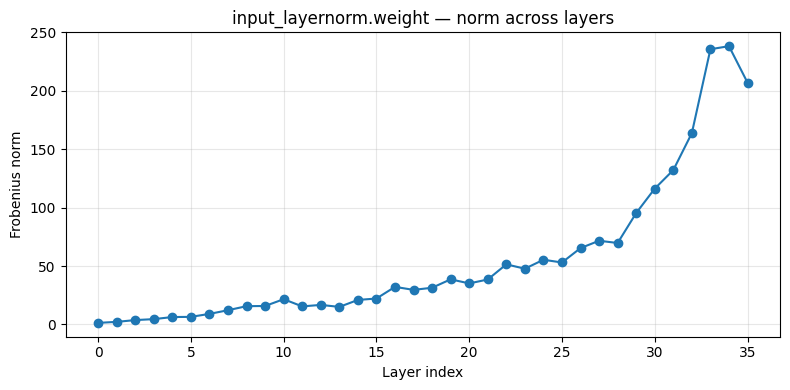

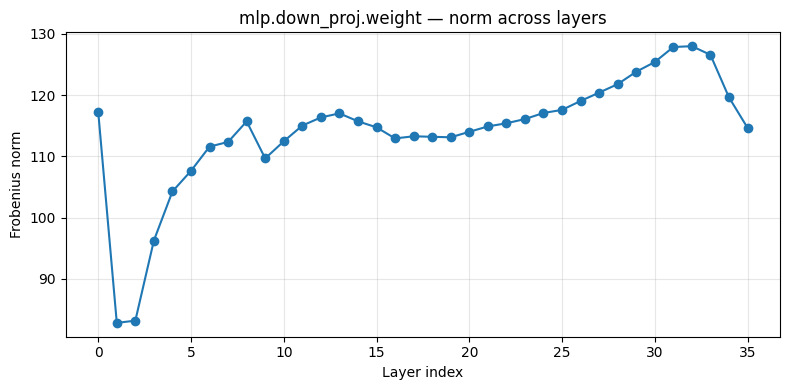

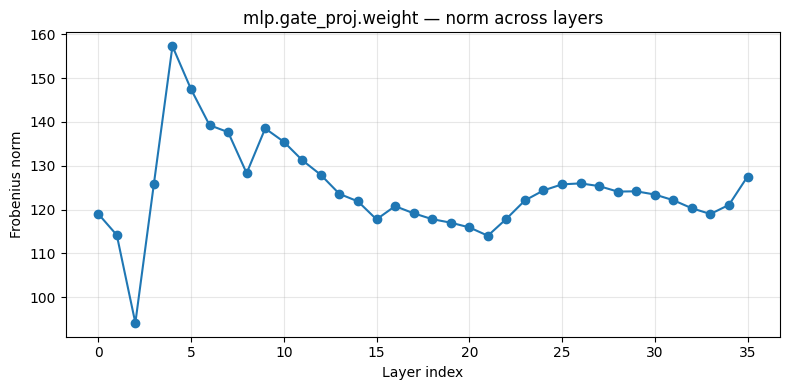

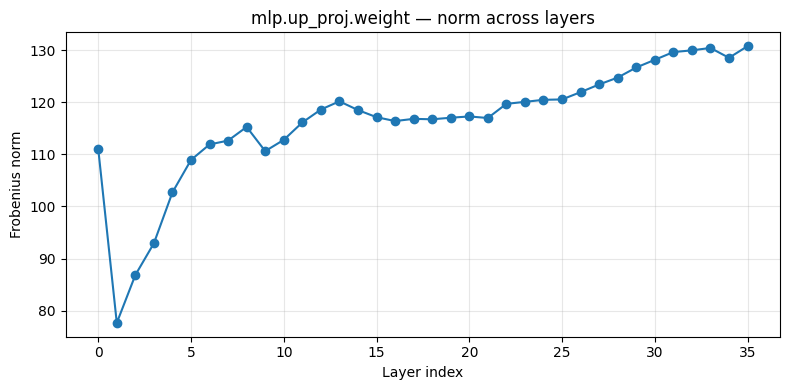

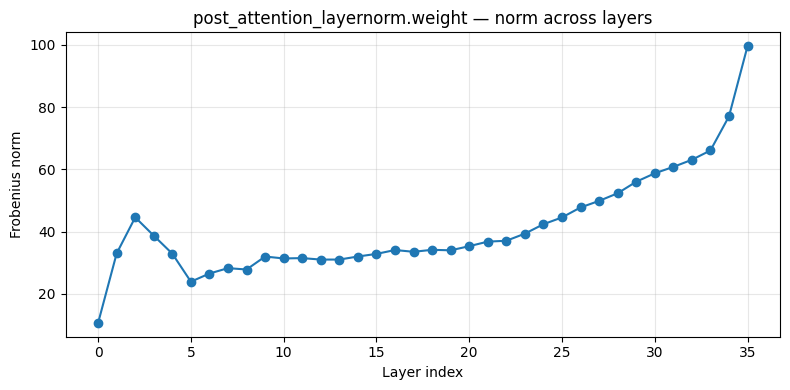

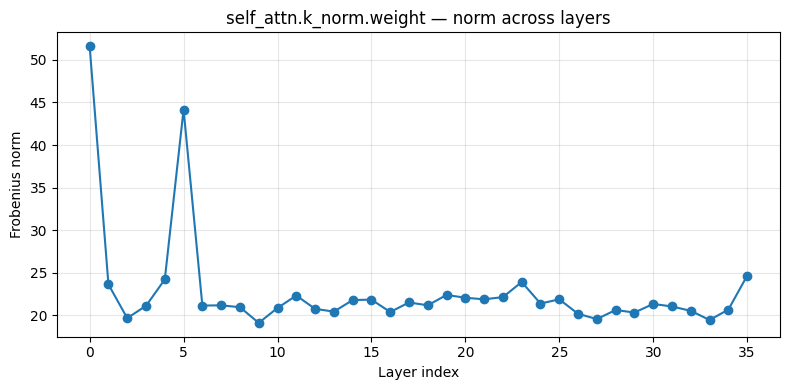

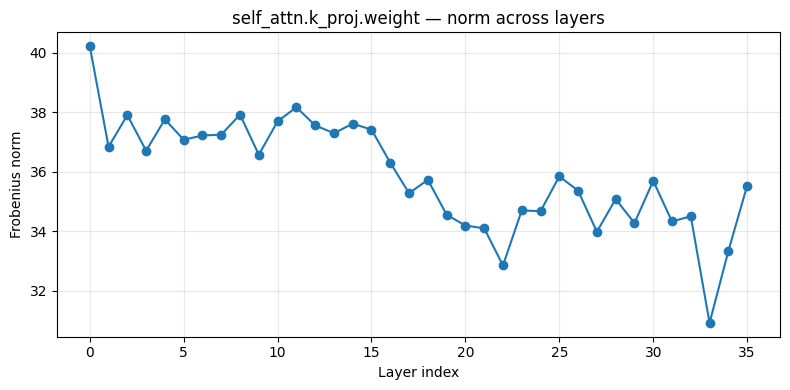

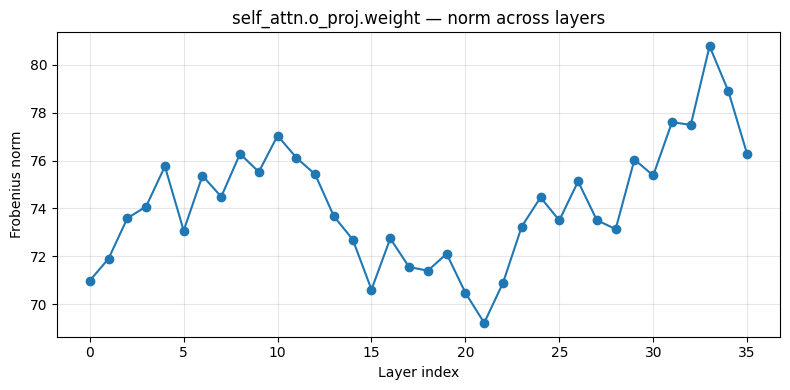

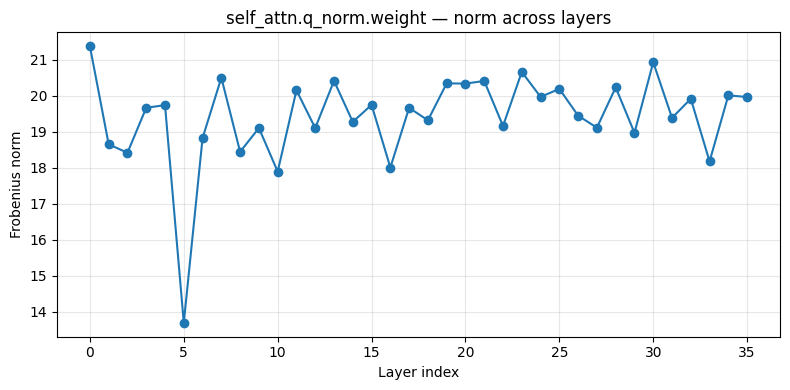

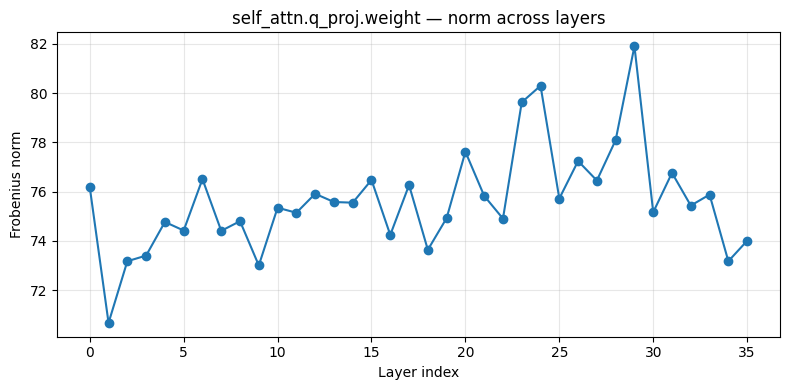

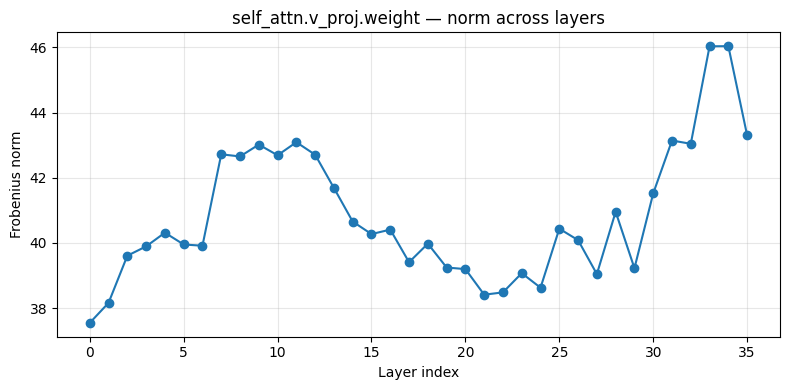

In [6]:
# One section (plot) per weight type: x = layer index, y = weight norm.
for weight_type in sorted(norms):
    layer_norms = norms[weight_type]
    layers = sorted(layer_norms)
    values = [layer_norms[l] for l in layers]

    plt.figure(figsize=(8, 4))
    plt.plot(layers, values, marker="o")
    plt.title(f"{weight_type} — norm across layers")
    plt.xlabel("Layer index")
    plt.ylabel("Frobenius norm")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Combined overview (all weight types on one figure, normalized subplots)

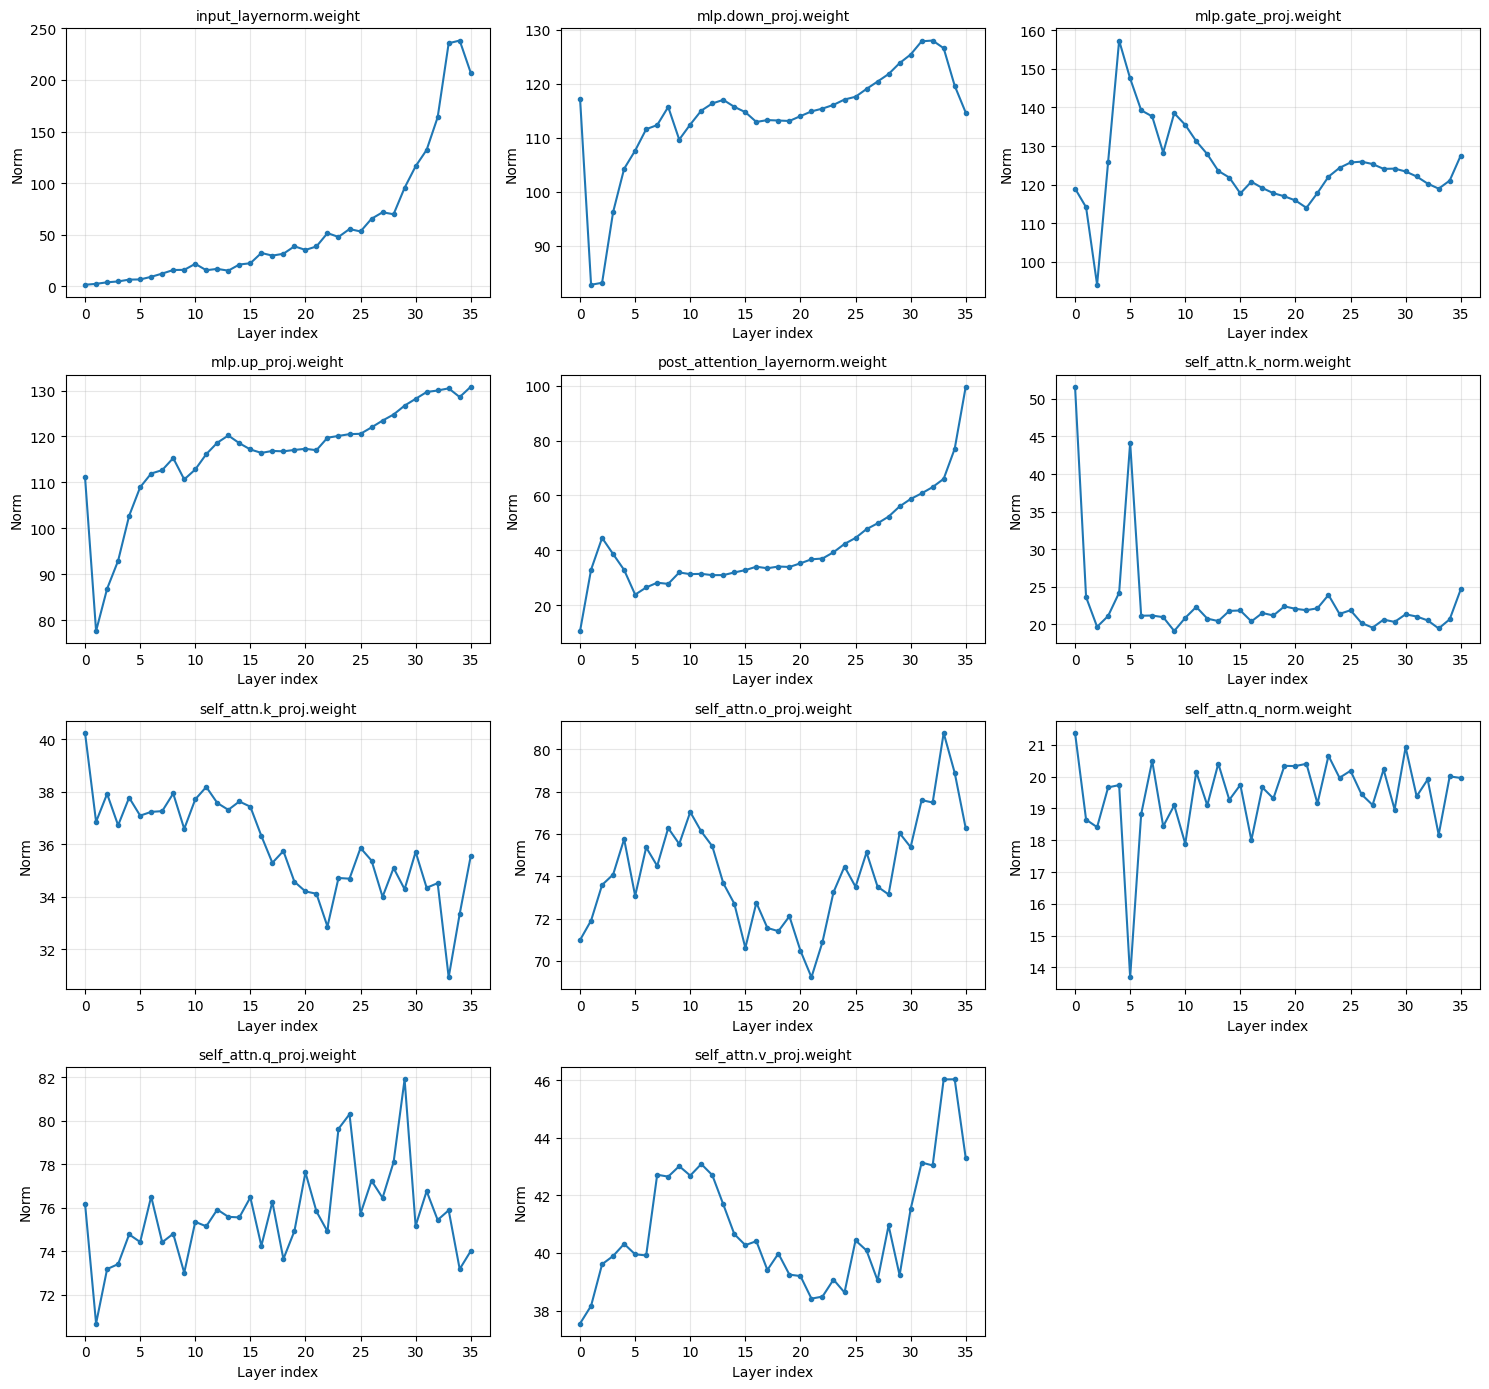

In [7]:
weight_types = sorted(norms)
n = len(weight_types)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for ax, weight_type in zip(axes, weight_types):
    layer_norms = norms[weight_type]
    layers = sorted(layer_norms)
    values = [layer_norms[l] for l in layers]
    ax.plot(layers, values, marker="o", markersize=3)
    ax.set_title(weight_type, fontsize=10)
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Norm")
    ax.grid(True, alpha=0.3)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Non per-layer weights (embedding, final norm)

In [ ]:
for name in non_layer_weights:
    t = get_tensor(name)
    print(f"{name}: shape={tuple(t.shape)}, norm={t.float().norm().item():.4f}")